In [1]:
import numpy as np
import sys
import os
import VBMicrolensing
import emcee
import h5py
import math
import matplotlib.pyplot as plt
import concurrent.futures
import corner
from tqdm import tqdm
VBM = VBMicrolensing.VBMicrolensing()
JD0 = 2450000
from matplotlib.lines import Line2D
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
gapmoe_model = gapmoe(rhos_path="/moao38_7/nunota/gapmoe/test_data/hist_D.dat",mass_path="/moao38_7/nunota/gapmoe/test_data/hist_M.dat",mu_path="/moao38_7/nunota/gapmoe/test_data/hist_murel.dat")
gapmoe_model.set_data()

import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import matplotlib as mpl
import pandas as pd
import arviz as az

In [2]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [3]:

mpl.rc('font', **{'family': 'serif', 'serif': ['Liberation Serif', 'DejaVu Serif']})
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [4]:
muE_correct   = 3.000003  # mas/yr
muN_correct   = 3.000001  # mas/yr
ML_correct       = 0.523489        # M_sun
DL_correct       = 3.663748      # kpc
DS_correct       = 8.142612        # kpc
mu_correct = np.sqrt(muE_correct**2 + muN_correct**2)
phi_mu_correct = np.arctan2(muE_correct,muN_correct)

In [5]:
def weighted_percentile(data, weights, percentiles=[16, 50, 84]):
    """Weighted percentile calculation"""
    sorter = np.argsort(data)
    data_sorted = data[sorter]
    weights_sorted = weights[sorter]
    cumsum = np.cumsum(weights_sorted)
    cumsum /= cumsum[-1]
    return np.interp(np.array(percentiles)/100, cumsum, data_sorted)

In [6]:
all_flat_samples = []
all_flat_lnprobs = []
all_flat_blobs = []

burnin = 3000
thin = 20

path = f"../test_result/chain/simu_02_chain.h5"
sampler = emcee.backends.HDFBackend(path)

flat_chain = sampler.get_chain(flat=True, discard=burnin, thin=thin)
flat_lnprob = sampler.get_log_prob(flat=True, discard=burnin, thin=thin)
flat_blob = sampler.get_blobs(flat=True, discard=burnin, thin=thin)

all_flat_samples.append(flat_chain)
all_flat_lnprobs.append(flat_lnprob)
all_flat_blobs.append(flat_blob)

joint_flat_samples = np.concatenate(all_flat_samples, axis=0)
joint_flat_lnprobs = np.concatenate(all_flat_lnprobs, axis=0)
joint_flat_thS = np.concatenate(all_flat_blobs, axis=0)

non_flat_chain = sampler.get_chain(flat=False, discard=burnin, thin=thin)
non_flat_lnprobs =  sampler.get_log_prob(flat=False, discard=burnin, thin=thin)

In [7]:
all_flat_samples = []
all_flat_lnprobs = []
all_flat_blobs = []

burnin = 3000
thin = 20

path = f"../test_result/chain/wo_gap_simu_02_new_chain.h5"
sampler = emcee.backends.HDFBackend(path)

flat_chain = sampler.get_chain(flat=True, discard=burnin, thin=thin)
flat_lnprob = sampler.get_log_prob(flat=True, discard=burnin, thin=thin)
flat_blob = sampler.get_blobs(flat=True, discard=burnin, thin=thin)

all_flat_samples.append(flat_chain)
all_flat_lnprobs.append(flat_lnprob)
all_flat_blobs.append(flat_blob)

joint_flat_samples_wo = np.concatenate(all_flat_samples, axis=0)
joint_flat_lnprobs_wo = np.concatenate(all_flat_lnprobs, axis=0)
joint_flat_thS_wo = np.concatenate(all_flat_blobs, axis=0)

non_flat_chain_wo = sampler.get_chain(flat=False, discard=burnin, thin=thin)
non_flat_lnprobs_wo =  sampler.get_log_prob(flat=False, discard=burnin, thin=thin)



In [8]:
path = f"../test_result/chain/simu_02_chain.h5"
sampler = emcee.backends.HDFBackend(path)
idata = az.from_emcee(sampler) 

ess = az.ess(idata)

print(ess)

path = f"../test_result/chain/wo_gap_simu_02_new_chain.h5"
sampler = emcee.backends.HDFBackend(path)
idata = az.from_emcee(sampler) 

ess = az.ess(idata)

print(ess)

<xarray.Dataset> Size: 96B
Dimensions:  ()
Data variables:
    var_0    float64 8B 57.94
    var_1    float64 8B 68.64
    var_2    float64 8B 55.62
    var_3    float64 8B 55.15
    var_4    float64 8B 59.62
    var_5    float64 8B 60.58
    var_6    float64 8B 65.45
    var_7    float64 8B 119.3
    var_8    float64 8B 141.3
    var_9    float64 8B 56.15
    var_10   float64 8B 75.21
    var_11   float64 8B 65.04
<xarray.Dataset> Size: 96B
Dimensions:  ()
Data variables:
    var_0    float64 8B 66.35
    var_1    float64 8B 76.12
    var_2    float64 8B 56.9
    var_3    float64 8B 71.92
    var_4    float64 8B 75.43
    var_5    float64 8B 65.76
    var_6    float64 8B 78.13
    var_7    float64 8B 191.5
    var_8    float64 8B 192.9
    var_9    float64 8B 64.88
    var_10   float64 8B 68.46
    var_11   float64 8B 86.77


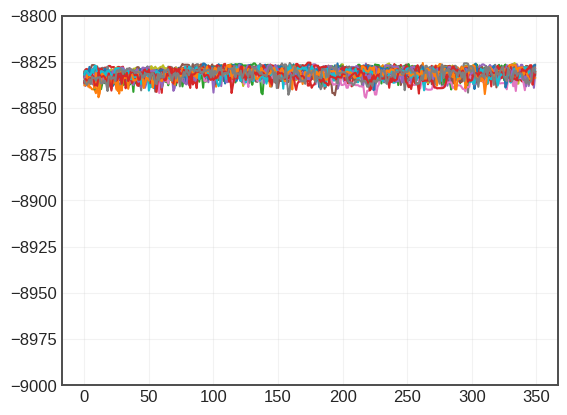

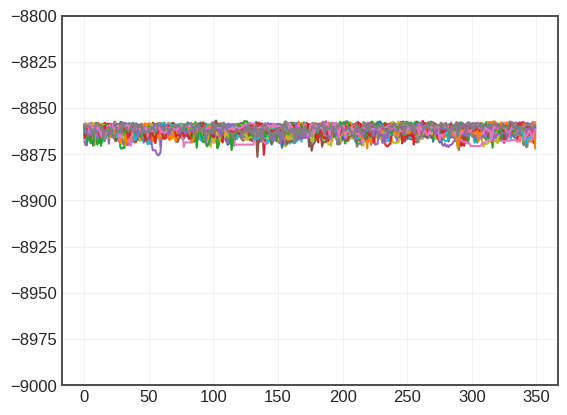

In [9]:
for i in range(non_flat_lnprobs.shape[1]):
    plt.plot(non_flat_lnprobs[:,i])
    
plt.minorticks_on()
plt.ylim(-9000,-8800)
plt.show()

for i in range(non_flat_lnprobs_wo.shape[1]):
    plt.plot(non_flat_lnprobs_wo[:,i])
    
plt.minorticks_on()
plt.ylim(-9000,-8800)
plt.show()

In [10]:
ind = np.where(joint_flat_lnprobs> -8900)
joint_flat_samples = joint_flat_samples[ind]
joint_flat_lnprobs = joint_flat_lnprobs[ind]
joint_flat_thS = joint_flat_thS[ind]

ind = np.where(joint_flat_lnprobs_wo> -8900)
joint_flat_samples_wo = joint_flat_samples_wo[ind]
joint_flat_lnprobs_wo = joint_flat_lnprobs_wo[ind]
joint_flat_thS_wo = joint_flat_thS_wo[ind]

In [11]:
kappa = 8.144; #mas /MO
G = 2.959122082855911e-4 

def calc_physical_params(x,thS):
    tE, rho, s, piEN, piEE, gamma1, gamma2, gamma3 = x
    piE = np.sqrt(piEE**2 + piEN**2)
    
    thE = thS / rho
    ML = thE / kappa / piE
    murel = thE / tE * 365.25
    murel_E = murel * piEE / piE
    murel_N = murel * piEN / piE

    gamma_sq = gamma1**2 + gamma2**2 + gamma3**2
    gamma_parallel = np.sqrt(gamma1**2 + gamma3**2)
    gamma_ratio = gamma_parallel / gamma3
    orbital_scale = np.cbrt((s**3) * gamma_sq * gamma_ratio / (ML * G))
    gamma_abs = np.sqrt(gamma_sq)
    Ds = 1 / ((orbital_scale - piE) * thE)

    pi_rel = thE * piE
    pi_S = 1 / Ds
    pi_L = pi_rel + pi_S
    DL = 1 / pi_L

    RE = DL * thE
    orbital_radi = RE * s * gamma_parallel / gamma3

    cosi = gamma3 * gamma2 / (gamma_parallel * gamma_abs)
    tanphi = - gamma1 * gamma_abs / (gamma3 * gamma_parallel)

    return np.array([murel_E, murel_N, ML, DL, Ds, orbital_radi, cosi, tanphi])

In [12]:
@jit
def calc_physical_params_jax(x,thS):
    tE, rho, s, piEN, piEE, gamma1, gamma2, gamma3 = x
    piE = jnp.sqrt(piEE**2 + piEN**2)
    
    thE = thS / rho
    ML = thE / kappa / piE
    murel = thE / tE * 365.25
    murel_E = murel * piEE / piE
    murel_N = murel * piEN / piE

    gamma_sq = gamma1**2 + gamma2**2 + gamma3**2
    gamma_parallel = jnp.sqrt(gamma1**2 + gamma3**2)
    gamma_ratio = gamma_parallel / gamma3
    orbital_scale = jnp.cbrt((s**3) * gamma_sq * gamma_ratio / (ML * G))
    gamma_abs = jnp.sqrt(gamma_sq)
    Ds = 1 / ((orbital_scale - piE) * thE)

    pi_rel = thE * piE
    pi_S = 1 / Ds
    pi_L = pi_rel + pi_S
    DL = 1 / pi_L

    RE = DL * thE
    orbital_radi = RE * s * gamma_parallel / gamma3

    cosi = gamma3 * gamma2 / (gamma_parallel * gamma_abs)
    tanphi = - gamma1 * gamma_abs / (gamma3 * gamma_parallel)

    return jnp.array([murel_E, murel_N, ML, DL, Ds, orbital_radi, cosi, tanphi])

@jit
def calc_ln_det_jacobian(x, thS):
    J = jacfwd(calc_physical_params_jax)(x, thS)
    _, lndet = jnp.linalg.slogdet(J)
    return lndet


In [13]:
physical_use_ind = np.array([1,6,4,7,8,9,10,11])
murel_E_array, murel_N_array, ML_array, DL_array, Ds_array, orbital_radi_array, cosi_array, tanphi_array  = calc_physical_params(joint_flat_samples.T[physical_use_ind],joint_flat_thS)
mu_abs_array = np.sqrt(murel_E_array**2 + murel_N_array**2)
mu_phi_array = np.arctan2(murel_E_array,murel_N_array)
MP_array = ML_array * joint_flat_samples[:,3] / (1 + joint_flat_samples[:,3])
use_ind = np.where((ML_array<3)&(DL_array<12)&(Ds_array<16)&(joint_flat_lnprobs>-16000)&(tanphi_array>-10)&(orbital_radi_array<30))

physical_array = np.array([ML_array[use_ind],DL_array[use_ind],
                           Ds_array[use_ind],mu_abs_array[use_ind],
                           mu_phi_array[use_ind],orbital_radi_array[use_ind],
                          cosi_array[use_ind],tanphi_array[use_ind],MP_array[use_ind]]).T

In [14]:
murel_E_array_wo, murel_N_array_wo, ML_array_wo, DL_array_wo, Ds_array_wo, \
orbital_radi_array_wo, cosi_array_wo, tanphi_array_wo = calc_physical_params(
    joint_flat_samples_wo.T[physical_use_ind], joint_flat_thS_wo
)
mu_abs_array_wo = np.sqrt(murel_E_array_wo**2 + murel_N_array_wo**2)
mu_phi_array_wo = np.arctan2(murel_E_array_wo, murel_N_array_wo)

q_wo = joint_flat_samples_wo[:, 3] 
MP_array_wo = ML_array_wo * q_wo / (1 + q_wo)

use_ind_wo = np.where(
    (ML_array_wo < 3) &
    (DL_array_wo < 12) &
    (DL_array_wo > 0) &
    (Ds_array_wo < 16) &
    (Ds_array_wo > 0) &
    (tanphi_array_wo > -10) &
    (orbital_radi_array_wo < 30)
)

physical_array_wo = np.array([
    ML_array_wo[use_ind_wo],
    DL_array_wo[use_ind_wo],
    Ds_array_wo[use_ind_wo],
    mu_abs_array_wo[use_ind_wo],
    mu_phi_array_wo[use_ind_wo],
    orbital_radi_array_wo[use_ind_wo],
    cosi_array_wo[use_ind_wo],
    tanphi_array_wo[use_ind_wo],
    MP_array_wo[use_ind_wo]
]).T

batched_ln_det_jacobian = vmap(calc_ln_det_jacobian, in_axes=(0, 0)) 
log_jac_weight_wo = batched_ln_det_jacobian(joint_flat_samples_wo[:, physical_use_ind], joint_flat_thS_wo)+ np.log(1/(1+tanphi_array_wo**2))
log_jac_weight_wo = log_jac_weight_wo[use_ind_wo[0]]

log_gap_weight = []
for ind in use_ind_wo[0]:
    tmp = gapmoe_model.log_galactic_prior(ML_array_wo[ind], 
                                          DL_array_wo[ind], Ds_array_wo[ind], mu_abs_array_wo[ind], mu_phi_array_wo[ind])
    log_gap_weight.append(tmp)
    
log_gap_weight = np.array(log_gap_weight)
log_total_weight = log_jac_weight_wo + log_gap_weight

log_total_weight -= np.max(log_total_weight)
total_weight  = np.exp(log_total_weight)
total_weight /= np.sum(total_weight)

In [15]:
tmp_array = np.array([ML_array[use_ind],DL_array[use_ind],
                           Ds_array[use_ind],
                           murel_N_array[use_ind],murel_E_array[use_ind],orbital_radi_array[use_ind],
                          cosi_array[use_ind],tanphi_array[use_ind],MP_array[use_ind]]).T

# --- インデックス展開と結合 ---
use_ind_flat = use_ind[0]
combined_array = np.hstack([
    joint_flat_samples[use_ind_flat],
    tmp_array
])
Msun_in_Mearth = 332946.0487
Mjup_in_Mearth = 317.83
# --- スケーリング ---
scaled_array = combined_array.copy()
scaled_array[:, 0] -= 10085   # t0 shift
scaled_array[:, 2] *= 1e2       # u0 × 10²
scaled_array[:, 3] *= 1e2       # q × 10²
scaled_array[:, 6] *= 1e3       # rho × 10³
scaled_array[:, 9:12] *= 1e3    # gamma1-3 × 10³
scaled_array[:,7] *= 1e2
scaled_array[:,8] *= 1e2
scaled_array[:,-1] *= Msun_in_Mearth / Mjup_in_Mearth

labels = [
    r"$t_0 - 10063.8$",   # 0
    r"$t_{\rm E}$",             # 1
    r"$u_0 \times 10^2$", # 2
    r"$q \times 10^2$",   # 3
    r"$s$",               # 4
    r"$\alpha$",          # 5
    r"$\rho \times 10^3$",# 6
    r"$\pi_{\rm E,N}\times 10^2$",       # 7
    r"$\pi_{\rm E,E}\times 10^2$",       # 8
    r"$\gamma_1 \times 10^3$",  # 9
    r"$\gamma_2 \times 10^3$",  # 10
    r"$\gamma_3 \times 10^3$",  # 11
    r"$M_{\rm L}$", r"$D_{\rm L}$", r"$D_{\rm S}$",
    r"$\mu_{\rm rel,N}$", r"$\mu_{\rm rel,E$", 
    r"$a$", r"$\cos{i}$", r"$\tan{\phi}$",r"$M_{\rm P}$"
]

# # --- corner plot ---
# fig = corner.corner(
#     scaled_array,
#     labels=labels,
#     show_titles=False,
#     title_fmt=".2f",
#     title_kwargs={"fontsize": 15},
#     label_kwargs={"fontsize": 20},
#     max_n_ticks=4,
#     plot_density=True,
#     plot_contours=True,
#     fill_contours=True,
#     color="C0",
#     hist_kwargs={"density": True, "alpha": 0.8},
# )

# # --- minor ticks ON ---
# for ax in fig.get_axes():
#     ax.minorticks_on()

# # --- タイトル ---
# plt.subplots_adjust(top=0.95)
# plt.show()

In [16]:
# --- インデックス展開と結合（wo）---
use_ind_flat_wo = use_ind_wo[0]
combined_array_wo = np.hstack([
    joint_flat_samples_wo[use_ind_flat_wo],
    physical_array_wo
])

# --- スケーリング（wo）---
scaled_array_wo = combined_array_wo.copy()
scaled_array_wo[:, 0] -= 10085   # t0 shift
scaled_array_wo[:, 2] *= 1e2       # u0 × 10²
scaled_array_wo[:, 3] *= 1e2       # q × 10²
scaled_array_wo[:, 6] *= 1e3       # rho × 10³
scaled_array_wo[:, 9:12] *= 1e3    # gamma1-3 × 10³
scaled_array_wo[:, 7] *= 1e2       # pi_E,N × 10²
scaled_array_wo[:, 8] *= 1e2       # pi_E,E × 10²
scaled_array_wo[:, -1] *= Msun_in_Mearth / Mjup_in_Mearth  # M_P in M_jup

# --- Corner plot（wo）---
fig = corner.corner(
    scaled_array_wo,
    labels=labels,
    show_titles=False,
    title_fmt=".2f",
    title_kwargs={"fontsize": 15},
    label_kwargs={"fontsize": 20},
    max_n_ticks=4,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,
    color="C3", 
    hist_kwargs={"density": True, "alpha": 0.8},
    weights=total_weight
)

corner.corner(
    scaled_array,
    fig=fig,
    labels=labels,
    show_titles=False,
    title_fmt=".2f",
    title_kwargs={"fontsize": 15},
    label_kwargs={"fontsize": 20},
    max_n_ticks=4,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,
    color="C0",
    hist_kwargs={"density": True, "alpha": 0.8},
)

# --- minor ticks ON ---
for ax in fig.get_axes():
    ax.minorticks_on()

# --- タイトル ---
plt.subplots_adjust(top=0.95)
plt.show()

ValueError: 
\mu_{\rm rel,E
              ^
ParseSyntaxException: Expected end_group, found end of text  (at char 14), (line:1, col:15)

<Figure size 4540x4540 with 441 Axes>

In [17]:
column_names = " wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L iS iL fREM".strip().split()

path_wo_lom = "../test_gal_result/genout_wo_lom_simu_02_copy.dat"
data_wo_lom = np.genfromtxt(path_wo_lom, names=column_names)

path_wo_para = "../test_gal_result/genout_wo_para_simu_02.dat"
data_wo_para = np.genfromtxt(path_wo_para, names=column_names)

path_prior = "../test_gal_result/genout_prior.dat"
data_prior = np.genfromtxt(path_prior, names=column_names)

In [18]:
non_uni_prior = np.load("../test_data/non_uniform_prior.npy")

non_uni_prior_ML =non_uni_prior[:, 2]
non_uni_prior_DL = non_uni_prior[:, 3]
non_uni_prior_Ds = non_uni_prior[:, 4]

In [19]:
fs = {"label": 16, "ticks": 14, "legend": 13}

draw_styles = {
    "main":        {"color": "black",      "linestyle": "-",  "linewidth": 5, "alpha": 1.0},
    "wo_jac_wt":   {"color": "red",        "linestyle": "-",  "linewidth": 5, "alpha": 0.9},
    "wo_jac":      {"color": "royalblue",  "linestyle": "--", "linewidth": 5, "alpha": 0.9},
    "data_lom":    {"color": "seagreen",   "linestyle": "--", "linewidth": 5, "alpha": 0.8},
    "data_para":   {"color": "darkorange", "linestyle": "-",  "linewidth": 5, "alpha": 0.8},
    "prior_flat":  {"color": "gray",       "linestyle": "--",  "linewidth": 5, "alpha": 0.6},
    "prior_nonuni":{"color": "gray",       "linestyle": "--", "linewidth": 5, "alpha": 0.6}
}

label_texts = {
    0: [("Full Bayesian (with Jacobian)", "main"), ("Flat prior", "prior_flat")],
    1: [("w/o Jacobian (weighted)", "wo_jac_wt"),
        ("w/o Jacobian (unweighted)", "wo_jac"),
        ("Non-uniform prior", "prior_nonuni")],
    2: [("Data (wo LOM)", "data_lom"),
        ("Data (wo Parallax)", "data_para"),
        ("Flat prior", "prior_flat")]
}

bins = {
    "ML": np.linspace(0, 1.2, 40),
    "DL": np.linspace(0, 12, 50),
    "DL_data": np.linspace(0, 12, 70),
    "DL_data_para": np.linspace(0, 12, 70),
    "DS": np.linspace(0, 16, 50),
    "DS_data": np.linspace(0, 18, 80)
}

xlabel_dict = {
    "ML": r"$M_{\rm L}\ [M_\odot]$",
    "DL": r"$D_{\rm L}\ [{\rm kpc}]$",
    "DS": r"$D_{\rm S}\ [{\rm kpc}]$"
}

ylim_dict = {
    "ML": (0, None),
    "DL": (0, None),
    "DS": (0, None)  # 自動スケール
}


In [20]:
def plot_variable_with_prior(var_name, array_main, array_wo,
                             data_lom_col, data_para_col,
                             wtj_lom, wtj_para,
                             prior_flat, prior_nonuni,
                             bins_main, bins_lom, bins_para,
                             xlabel, ylim):

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 8), sharex=True)

    # ----- 1段目: Full Bayesian -----
    axes[0].hist(prior_flat, bins=bins_main, density=True,
                 histtype="step", zorder=5, **draw_styles["prior_flat"])
    axes[0].hist(array_main, bins=bins_main, density=True,
                 histtype="step", zorder=10, **draw_styles["main"])
    axes[0].tick_params(labelsize=fs["ticks"])
    axes[0].set_ylim(ylim)

    # ----- 2段目: w/o Jacobian -----
    axes[1].hist(prior_nonuni, bins=bins_main, density=True,
                 histtype="step", zorder=5, **draw_styles["prior_nonuni"])
    axes[1].hist(array_wo, bins=bins_main, density=True,
                 weights=total_weight, histtype="step", zorder=9, **draw_styles["wo_jac_wt"])
    axes[1].hist(array_wo, bins=bins_main, density=True,
                 histtype="step", zorder=10, **draw_styles["wo_jac"])
    axes[1].tick_params(labelsize=fs["ticks"])
    axes[1].set_ylim(ylim)

    # ----- 3段目: 2-step approach -----
    axes[2].hist(prior_flat, bins=bins_main, density=True,
                 histtype="step", zorder=5, **draw_styles["prior_flat"])
    axes[2].hist(data_lom_col, bins=bins_lom, density=True,
                 weights=wtj_lom, histtype="step", zorder=7, **draw_styles["data_lom"])
    axes[2].hist(data_para_col, bins=bins_para, density=True,
                 weights=wtj_para, histtype="step", zorder=6, **draw_styles["data_para"])
    axes[2].set_xlabel(xlabel, fontsize=fs["label"])
    axes[2].tick_params(labelsize=fs["ticks"])
    axes[2].set_ylim(ylim)

    # ----- ラベル描画（draw_styles 参照） -----
    for i, label_group in label_texts.items():
        for j, (text, key_or_color) in enumerate(label_group):
            color = draw_styles[key_or_color]["color"] if key_or_color in draw_styles else key_or_color
            y_pos = 0.9 - j * 0.08
            axes[i].text(0.95, y_pos, text,
                         transform=axes[i].transAxes,
                         ha="right", va="top",
                         fontsize=fs["legend"],
                         color=color)

    for ax in axes:
        ax.minorticks_on()

    plt.tight_layout()
    return axes

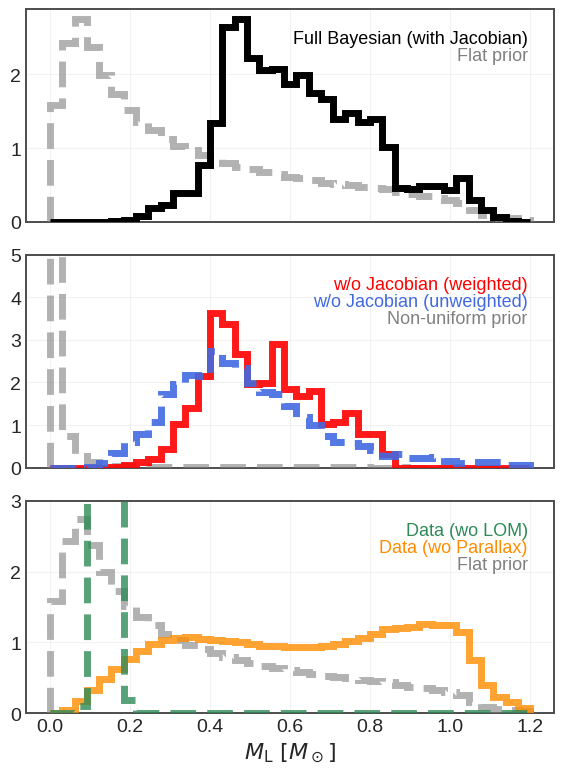

In [21]:
# -------- 各変数の描画 -------- #
# M_L
ax = plot_variable_with_prior(
    var_name="ML",
    array_main=ML_array[use_ind],
    array_wo=ML_array_wo[use_ind_wo],
    data_lom_col=data_wo_lom["M_L"],
    data_para_col=data_wo_para["M_L"],
    wtj_lom=data_wo_lom["wtj"],
    wtj_para=data_wo_para["wtj"],
    prior_flat=data_prior["M_L"],
    prior_nonuni=non_uni_prior_ML,
    bins_main=bins["ML"],
    bins_lom=bins["ML"],
    bins_para=bins["ML"],
    xlabel=xlabel_dict["ML"],
    ylim=ylim_dict["ML"]
)

ax[1].set_ylim(0,5)
ax[2].set_ylim(0,3)

plt.show()

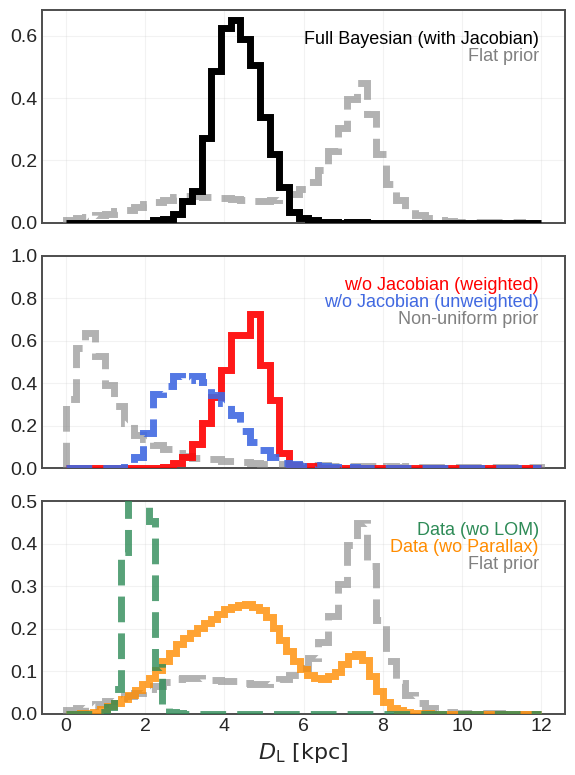

In [22]:
# D_L
ax = plot_variable_with_prior(
    var_name="DL",
    array_main=DL_array[use_ind],
    array_wo=DL_array_wo[use_ind_wo],
    data_lom_col=data_wo_lom["D_L"] * 1e-3,
    data_para_col=data_wo_para["D_L"] * 1e-3,
    wtj_lom=data_wo_lom["wtj"],
    wtj_para=data_wo_para["wtj"],
    prior_flat=data_prior["D_L"] * 1e-3,
    prior_nonuni=non_uni_prior_DL,
    bins_main=bins["DL"],
    bins_lom=bins["DL_data"],
    bins_para=bins["DL_data_para"],
    xlabel=xlabel_dict["DL"],
    ylim=ylim_dict["DL"]
)

ax[1].set_ylim(0,1)
ax[2].set_ylim(0,0.5)
plt.show()

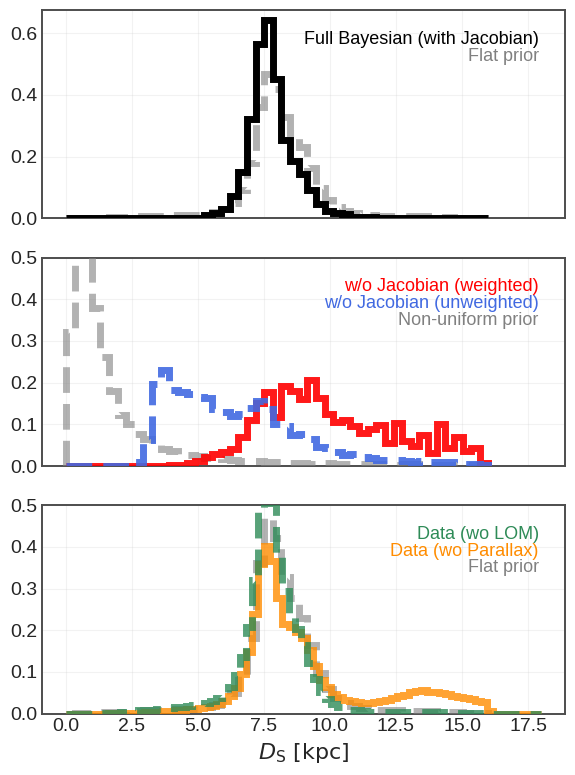

In [23]:

# D_S
ax = plot_variable_with_prior(
    var_name="DS",
    array_main=Ds_array[use_ind],
    array_wo=Ds_array_wo[use_ind_wo],
    data_lom_col=data_wo_lom["D_S"] * 1e-3,
    data_para_col=data_wo_para["D_S"] * 1e-3,
    wtj_lom=data_wo_lom["wtj"],
    wtj_para=data_wo_para["wtj"],
    prior_flat=data_prior["D_S"] * 1e-3,
    prior_nonuni=non_uni_prior_Ds,
    bins_main=bins["DS"],
    bins_lom=bins["DS_data"],
    bins_para=bins["DS_data"],
    xlabel=xlabel_dict["DS"],
    ylim=ylim_dict["DS"]
)

ax[1].set_ylim(0,0.5)
ax[2].set_ylim(0,0.5)
plt.show()

In [24]:
# ----- log10スケール変換 -----
logML = np.log10(physical_array[:, 0])
logDL = np.log10(physical_array[:, 1])
logDS = np.log10(physical_array[:, 2])

logML_wo = np.log10(physical_array_wo[:, 0])
logDL_wo = np.log10(physical_array_wo[:, 1])
logDS_wo = np.log10(physical_array_wo[:, 2])

logML_wo_lom = np.log10(data_wo_lom["M_L"])
logDL_wo_lom = np.log10(data_wo_lom["D_L"] * 1e-3)
logDS_wo_lom = np.log10(data_wo_lom["D_S"] * 1e-3)

logML_wo_para = np.log10(data_wo_para["M_L"])
logDL_wo_para = np.log10(data_wo_para["D_L"] * 1e-3)
logDS_wo_para = np.log10(data_wo_para["D_S"] * 1e-3)

# ----- μ_E, μ_N の抽出 -----
mu_rel = mu_abs_array[use_ind]
phi_mu = mu_phi_array[use_ind]

mu_rel_wo = mu_abs_array_wo[use_ind_wo]
phi_mu_wo = mu_phi_array_wo[use_ind_wo]

mu_rel_N_wo_lom = data_wo_lom["mu_rel"] * data_wo_lom["pi_EN"] / data_wo_lom["pi_E"]
mu_rel_E_wo_lom = data_wo_lom["mu_rel"] * data_wo_lom["pi_EE"] / data_wo_lom["pi_E"]

mu_rel_N_wo_para = data_wo_para["mu_rel"] * data_wo_para["pi_EN"] / data_wo_para["pi_E"]
mu_rel_E_wo_para = data_wo_para["mu_rel"] * data_wo_para["pi_EE"] /  data_wo_para["pi_E"]

In [25]:
post_array = np.vstack([logML, logDL, logDS, murel_N_array[use_ind],murel_E_array[use_ind]]).T
post_array_wo = np.vstack([logML_wo, logDL_wo, logDS_wo, murel_N_array_wo[use_ind_wo], murel_E_array_wo[use_ind_wo]]).T

post_array_wo_lom = np.vstack([
    logML_wo_lom, logDL_wo_lom, logDS_wo_lom,
    mu_rel_N_wo_lom, mu_rel_E_wo_lom
]).T

post_array_wo_para = np.vstack([
    logML_wo_para, logDL_wo_para, logDS_wo_para,
    mu_rel_N_wo_para, mu_rel_E_wo_para
]).T

In [26]:
labels_phys_muEN = [
    r"$\log_{10}(M_{\rm L}/M_\odot)$",
    r"$\log_{10}(D_{\rm L}/{\rm kpc})$",
    r"$\log_{10}(D_{\rm S}/{\rm kpc})$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$"
]

truths = [
    np.log10(ML_correct),
    np.log10(DL_correct),
    np.log10(DS_correct),
    muN_correct,
    muE_correct
]

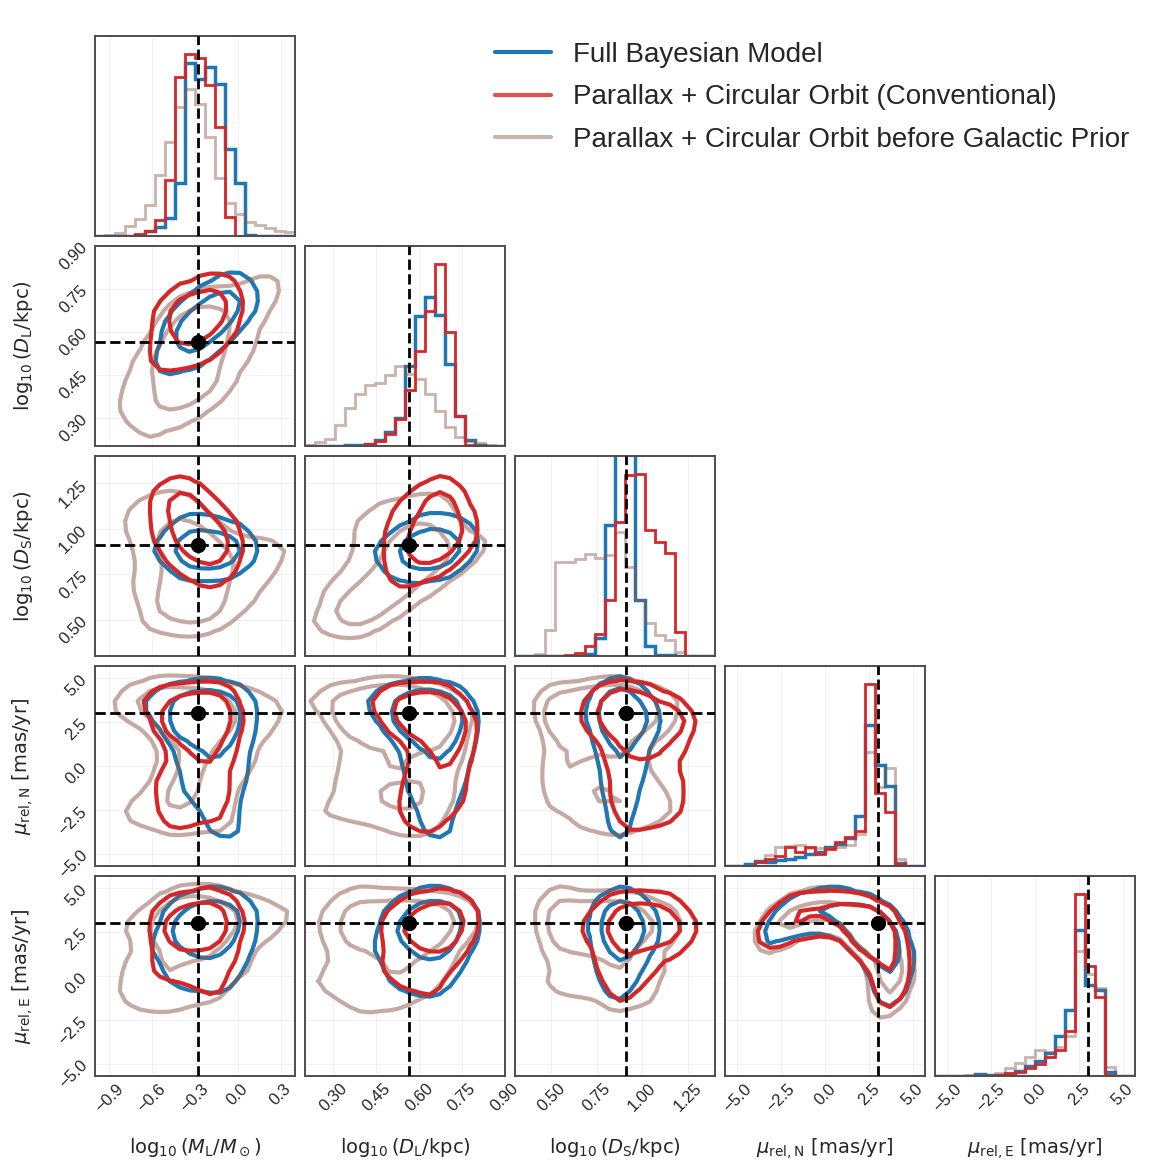

In [27]:
ranges = [
    (-1, 0.4),       # logML
    (0.2, .9),      # logDL
    (0.3, 1.4),      # logDS
    (-5.7, 5.7),         # mu_rel_N
    (-5.7, 5.7)        # mu_rel_E
]

# --- Base: Full Bayesian (black) ---
fig = corner.corner(
    post_array,
    labels=labels_phys_muEN,
    color="C0",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    levels=(0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    range=ranges
)

# --- Blue: unweighted posterior ---
corner.corner(
    post_array_wo,
    fig=fig,
    color="C5",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.45},
    contour_kwargs={"zorder": 6, "linewidths": 3,"alpha":0.5},
    levels=(0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    range=ranges
)

# --- Red: weighted posterior ---
corner.corner(
    post_array_wo,
    fig=fig,
    weights=total_weight,
    color="C3",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 1},
    contour_kwargs={"zorder": 7, "linewidths": 3,"alpha":1},
    levels=(0.68, 0.95),
    fill_contours=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    range=ranges
)

# --- 軸補助設定 ---
ndim = post_array.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True)
        
ndim = len(truths)
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", markersize=10, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
    
for i in range(ndim):
    ax = axes[i, i]
    ax.set_ylim(bottom=0)
    ymax = 0
    for line in ax.lines:
        if line.get_linestyle() != '--':
            ydata = line.get_ydata()
            if ydata is not None and len(ydata) > 0:
                ymax = max(ymax, max(ydata))
    if ymax > 0:
        ax.set_ylim(top=ymax * 1.1)

legend_handles = [
    Line2D([0], [0], color="C0", lw=3, label="Full Bayesian Model"),
    Line2D([0], [0], color="C3", lw=3, alpha=0.8, label="Parallax + Circular Orbit (Conventional)"),
    Line2D([0], [0], color="C5", lw=3, alpha=0.45, label="Parallax + Circular Orbit before Galactic Prior"),
]

# legend を corner の Figure に直接追加
fig.legend(
    handles=legend_handles,
    loc="upper right",     # 枠内の右上（他候補: 'lower left', 'center right', 'upper center' など）
    fontsize=20,
    frameon=False,
    framealpha=0.9,
    borderpad=1,
    labelspacing=0.6,
)

plt.savefig("../test_figures/simu_02_corner_01.pdf")

plt.show()

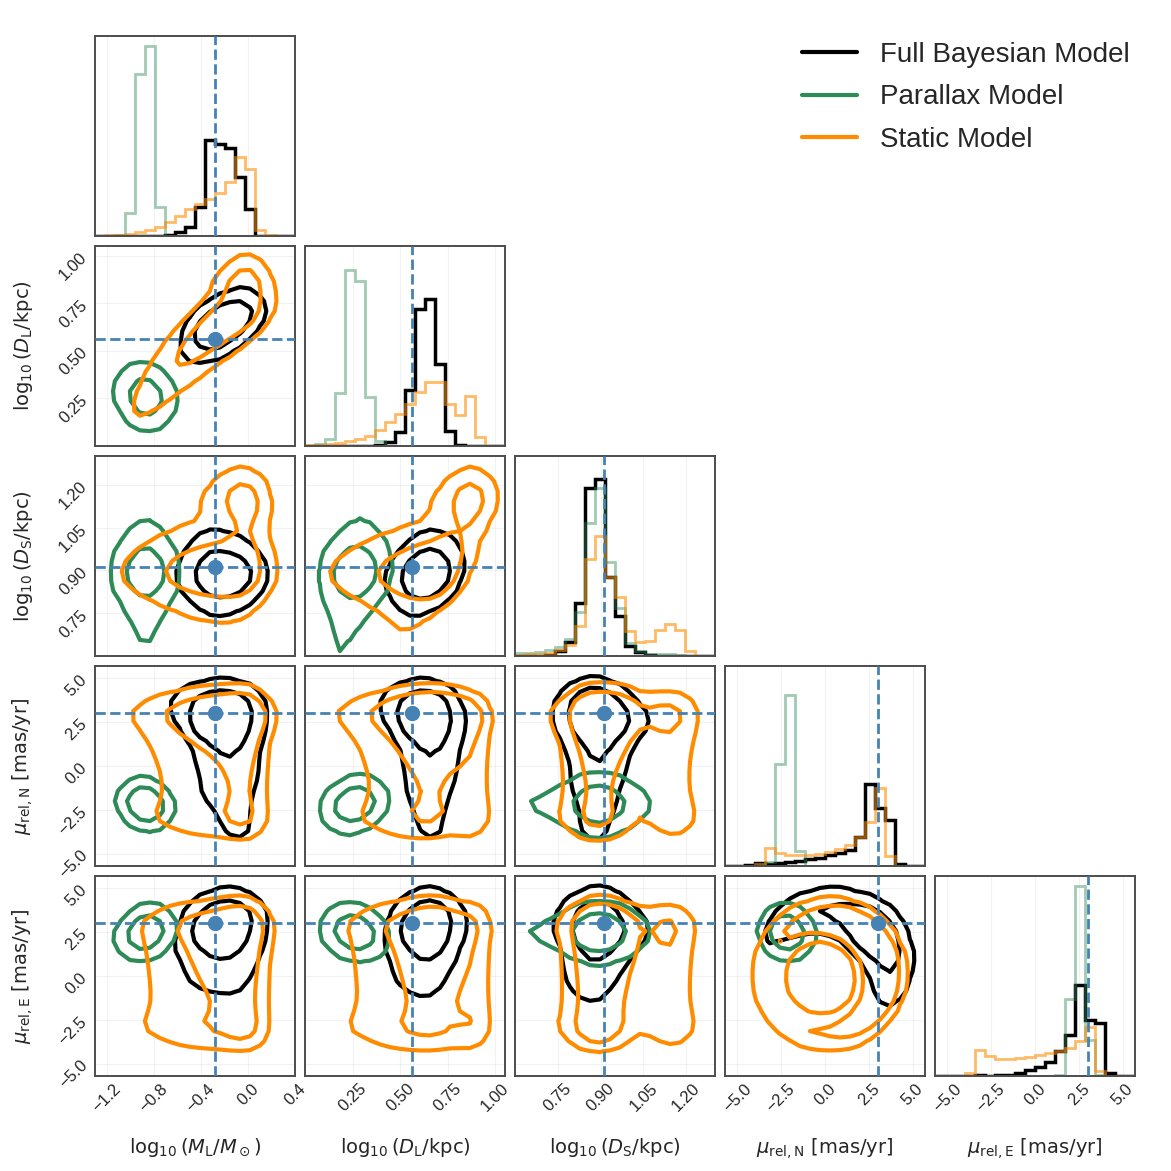

In [28]:
ranges = [
    (-1.3, 0.4),       # logML
    (0.0, 1.05),      # logDL
    (0.6, 1.3),      # logDS
    (-5.7, 5.7),         # mu_rel_N
    (-5.7, 5.7)        # mu_rel_E
]

fig = corner.corner(
    post_array,
    labels=labels_phys_muEN,
    color="black",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    levels=(0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    range=ranges
)

corner.corner(
    post_array_wo_lom,
    fig=fig,
    color="seagreen",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.45},
    contour_kwargs={"zorder": 6, "linewidths": 3, "alpha": 1},
    levels=(0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    weights=data_wo_lom["wtj"],
    range=ranges
)

corner.corner(
    post_array_wo_para,
    fig=fig,
    color="darkorange",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.6},
    contour_kwargs={"zorder": 7, "linewidths": 3},
    levels=(0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    weights=data_wo_para["wtj"],
    range=ranges
)

ndim = post_array.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True)
        
ndim = len(truths)
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="steelblue", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="steelblue", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="steelblue", markersize=10, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="steelblue", linestyle="--", lw=2, zorder=9)
    
        
diag_ylims = [5.8,8.3,10.3,1.2,1.15]
for i in range(ndim):
    ax = axes[i, i]
    ax.set_ylim(bottom=0)
    ax.set_ylim(top=diag_ylims[i])  
    
    
legend_handles = [
    Line2D([0], [0], color="black", lw=3, label="Full Bayesian Model"),
    Line2D([0], [0], color="seagreen", lw=3, label="Parallax Model"),
    Line2D([0], [0], color="darkorange", lw=3, label="Static Model"),
]
# legend を corner の Figure に直接追加
fig.legend(
    handles=legend_handles,
    loc="upper right",     # 枠内の右上（他候補: 'lower left', 'center right', 'upper center' など）
    fontsize=20,
    frameon=False,
    framealpha=0.9,
    borderpad=1,
    labelspacing=0.6,
)

plt.savefig("../test_figures/simu_02_corner_02.pdf")

plt.show()

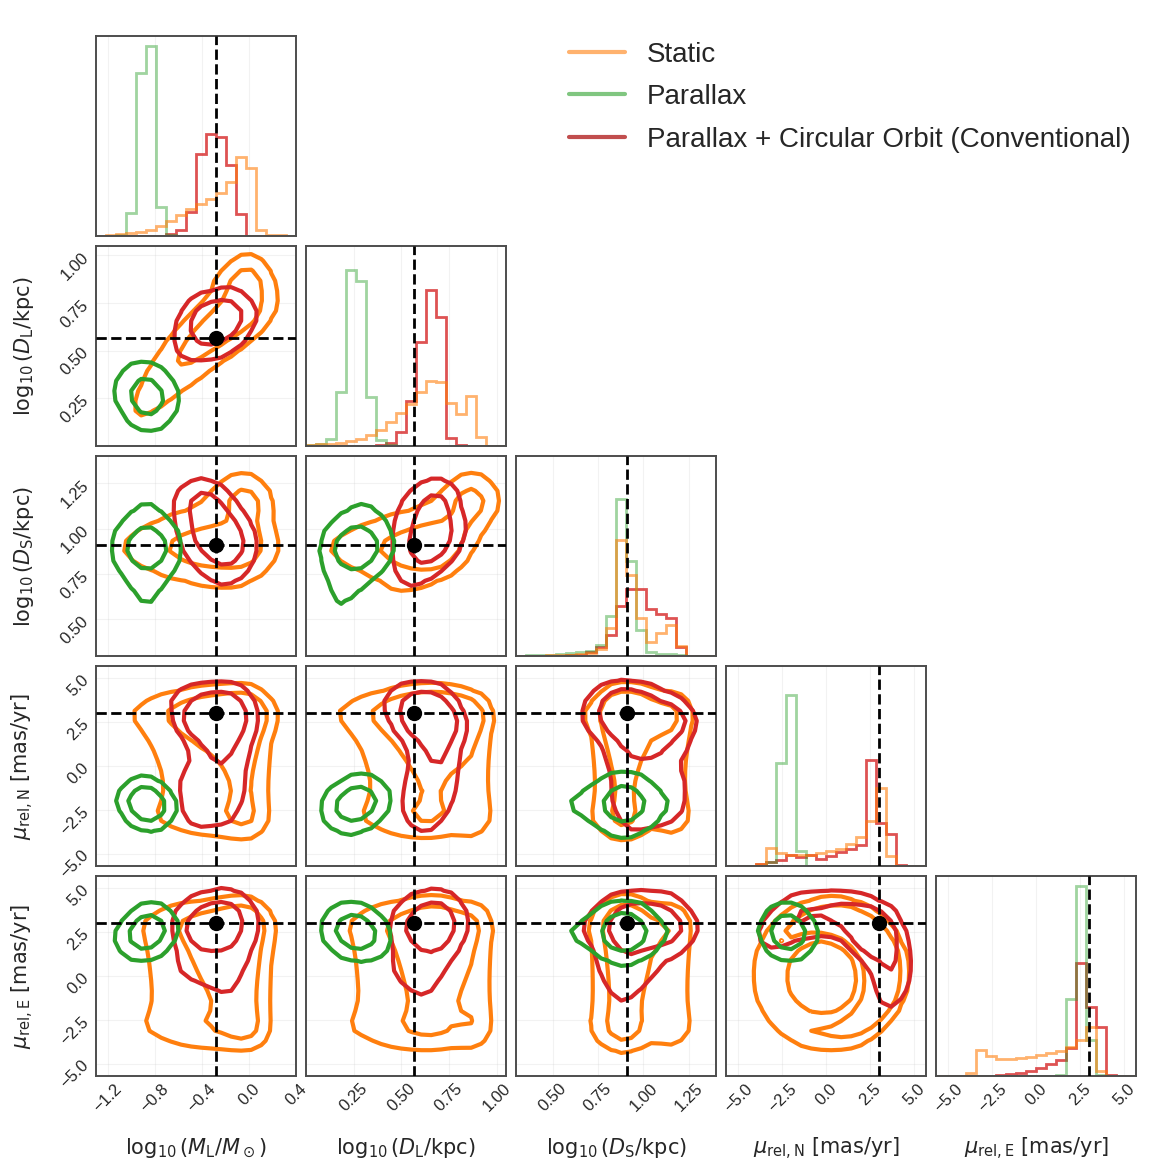

In [29]:
xlims = [
    (-1.3, 0.4),       # logML
    (0.0, 1.05),      # logDL
    (0.3, 1.4),      # logDS
    (-5.7, 5.7),         # mu_rel_N
    (-5.7, 5.7)        # mu_rel_E
]


# --- 薄赤: Unweighted Posterior (C5) ---
# fig = corner.corner(
#     post_array_wo,
#     labels=labels_phys_muEN,
#     color="C5",
#     hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.45},
#     label_kwargs={"fontsize": 14},
#     contour_kwargs={"zorder": 10, "linewidths": 3, "alpha": 0.45},
#     levels=(0.68, 0.95),
#     fill_contours=False,
#     show_titles=False,
#     plot_density=False,
#     plot_datapoints=False,
#     smooth=1.0,
#     range=xlims
# )

# --- 濃赤: Weighted Posterior (firebrick) ---
fig = corner.corner(
    post_array_wo,
    labels=labels_phys_muEN,
    color="C3",
    weights=total_weight,
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.8},
    contour_kwargs={"zorder": 11, "linewidths": 3},
    levels=(0.68, 0.95),
    fill_contours=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    range=xlims
)

# --- 緑: Parallax-only Model ---
corner.corner(
    post_array_wo_lom,
    fig=fig,
    color="C2",
    weights=data_wo_lom["wtj"],
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.45},
    contour_kwargs={"zorder": 13, "linewidths": 3},
    levels=(0.68, 0.95),
    fill_contours=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    range=xlims
)

# --- オレンジ: Static Model ---
corner.corner(
    post_array_wo_para,
    fig=fig,
    color="C1",
    weights=data_wo_para["wtj"],
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.6},
    contour_kwargs={"zorder": 8, "linewidths": 3},
    levels=(0.68, 0.95),
    fill_contours=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    range=xlims
)

# -------------------------------
# 軸と真値ライン
# -------------------------------
ndim = len(xlims)
axes = np.array(fig.axes).reshape((ndim, ndim))

# 軸設定
for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True)
        if i == j:
            ax.set_xlim(xlims[i])
        elif i > j:
            ax.set_xlim(xlims[j])
            ax.set_ylim(xlims[i])

# 真値ライン・点
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=15)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=15)
        ax.plot(truths[j], truths[i], "o", color="k", markersize=10, zorder=15)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=15)
    
    
diag_ylims = [5.8,8.3,10.3,1.2,1.15]
for i in range(ndim):
    ax = axes[i, i]
    ax.set_ylim(bottom=0)
    ax.set_ylim(top=diag_ylims[i])  


# -------------------------------
# 凡例
# -------------------------------
legend_handles = [
    Line2D([0], [0], color="C1", lw=3, alpha=0.6, label="Static"),
    Line2D([0], [0], color="C2", lw=3, alpha=0.6, label="Parallax"),
    Line2D([0], [0], color="firebrick", lw=3, alpha=0.8, label="Parallax + Circular Orbit (Conventional)"),
#     Line2D([0], [0], color="C5", lw=3, alpha=0.45, label="Parallax + Circular Orbit before Galactic Prior"),

]

fig.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=20,
    frameon=False,
    borderpad=1,
    labelspacing=0.6,
)

# -------------------------------
# 保存 & 表示
# -------------------------------
plt.savefig("../test_figures/simu_02_corner_03.pdf")
plt.show()

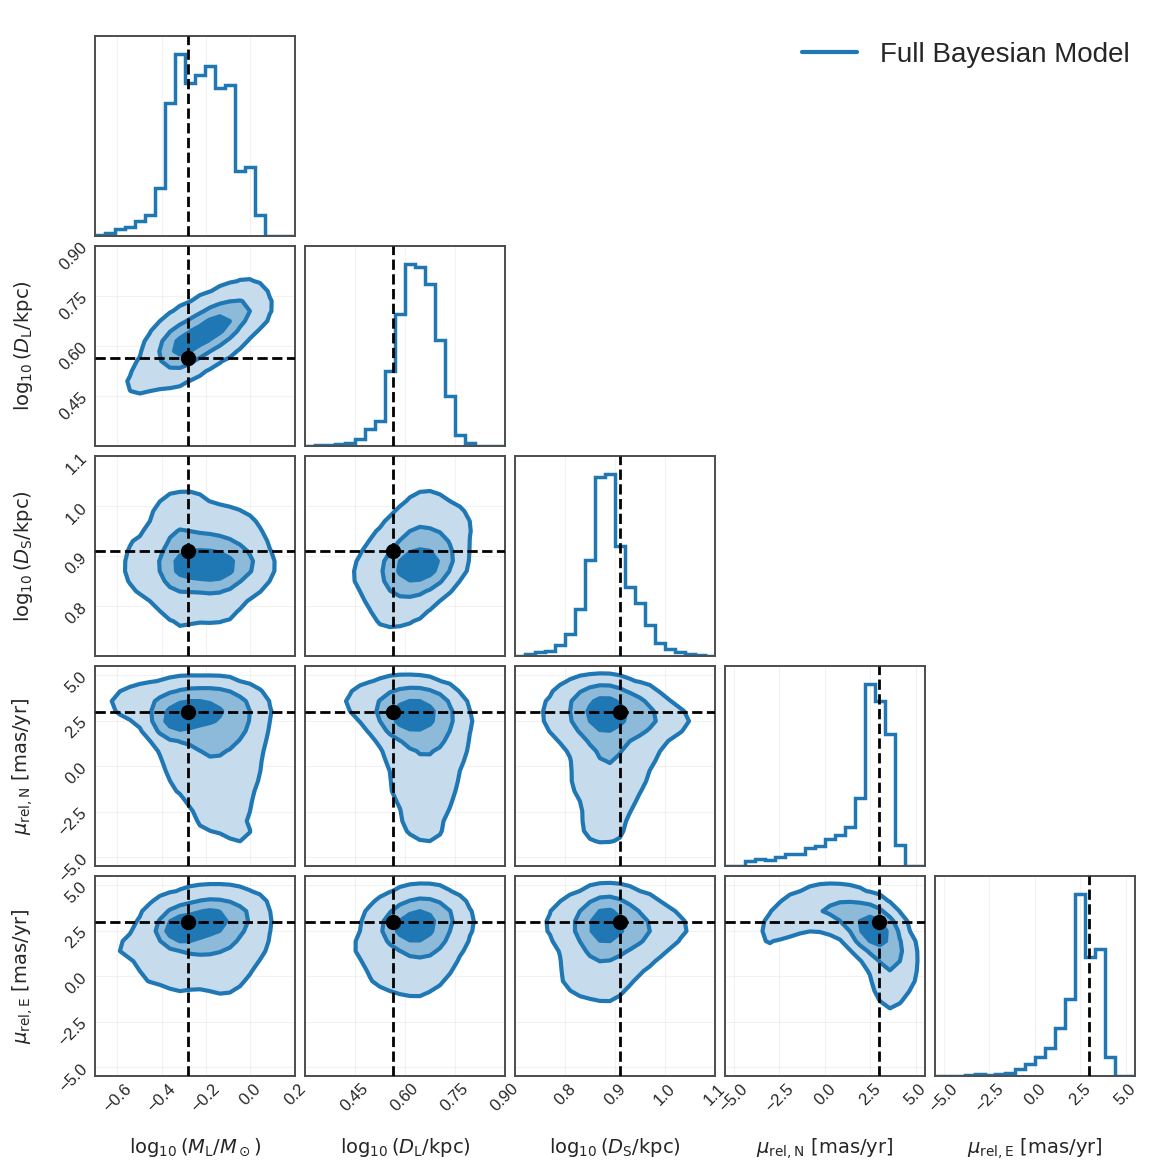

In [30]:
ranges = [
    (-.7, 0.2),       # logML
    (0.3, .9),      # logDL
    (0.7, 1.1),      # logDS
    (-5.5, 5.5),         # mu_rel_N
    (-5.5, 5.5)        # mu_rel_E
]
# --- Base: Full Bayesian (black) ---
fig = corner.corner(
    post_array,
    labels=labels_phys_muEN,
    color="C0",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    levels=(0.3,0.68, 0.95),
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    range=ranges
)


# --- 軸補助設定 ---
ndim = post_array.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True)
        
ndim = len(truths)
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", markersize=10, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
    
legend_handles = [
    Line2D([0], [0], color="C0", lw=3, label="Full Bayesian Model"),
]

# legend を corner の Figure に直接追加
fig.legend(
    handles=legend_handles,
    loc="upper right",     # 枠内の右上（他候補: 'lower left', 'center right', 'upper center' など）
    fontsize=20,
    frameon=False,
    framealpha=0.9,
    borderpad=1,
    labelspacing=0.6,
)

plt.savefig("../test_figures/simu_02_corner_04.pdf")
plt.show()

In [31]:
def format_latex_entry(p16, p50, p84, ndigits=4):
    return f"${p50:.{ndigits}f}_{{-{p50 - p16:.{ndigits}f}}}^{{+{p84 - p50:.{ndigits}f}}}$"

print(r"\begin{deluxetable*}{cc}")
print(r"\tablecaption{Median and 68\% Uncertainties for KB230598\label{table-full-corner}}")
print(r"\tablehead{\colhead{Parameter} & \colhead{Value}}")
print(r"\startdata")

for i, label in enumerate(labels):
    p16, p50, p84 = weighted_percentile(scaled_array_wo[:, i], total_weight,[16, 50, 84])
    entry = format_latex_entry(p16, p50, p84, ndigits=4)
    print(f"{label} & {entry} \\\\")

print(r"\enddata")
print(r"\tablecomments{Uncertainties represent the 68\% credible intervals.}")
print(r"\end{deluxetable*}")

\begin{deluxetable*}{cc}
\tablecaption{Median and 68\% Uncertainties for KB230598\label{table-full-corner}}
\tablehead{\colhead{Parameter} & \colhead{Value}}
\startdata
$t_0 - 10063.8$ & $0.0144_{-0.0070}^{+0.0089}$ \\
$t_{\rm E}$ & $69.0185_{-1.8225}^{+2.7775}$ \\
$u_0 \times 10^2$ & $1.0069_{-0.0429}^{+0.0264}$ \\
$q \times 10^2$ & $0.4894_{-0.0187}^{+0.0211}$ \\
$s$ & $0.9503_{-0.0010}^{+0.0008}$ \\
$\alpha$ & $2.9461_{-0.0034}^{+0.0037}$ \\
$\rho \times 10^3$ & $0.0893_{-0.0054}^{+0.0060}$ \\
$\pi_{\rm E,N}\times 10^2$ & $10.7308_{-12.0366}^{+4.5880}$ \\
$\pi_{\rm E,E}\times 10^2$ & $12.4353_{-5.0487}^{+3.4716}$ \\
$\gamma_1 \times 10^3$ & $0.7203_{-0.3082}^{+0.2327}$ \\
$\gamma_2 \times 10^3$ & $1.6671_{-0.2231}^{+0.1548}$ \\
$\gamma_3 \times 10^3$ & $0.9585_{-0.4340}^{+0.6220}$ \\
$M_{\rm L}$ & $0.5145_{-0.1158}^{+0.1640}$ \\
$D_{\rm L}$ & $4.5120_{-0.6640}^{+0.4808}$ \\
$D_{\rm S}$ & $9.4898_{-1.9666}^{+3.3277}$ \\
$\mu_{\rm rel,N}$ & $3.7090_{-0.2220}^{+0.1921}$ \\
$\mu_{\rm re

In [32]:
print(r"\begin{deluxetable*}{cc}")
print(r"\tablecaption{Median and 68\% Uncertainties for KB230598\label{table-full-corner}}")
print(r"\tablehead{\colhead{Parameter} & \colhead{Value}}")
print(r"\startdata")

for i, label in enumerate(labels):
    p16, p50, p84 = np.percentile(scaled_array[:, i],[16, 50, 84])
    entry = format_latex_entry(p16, p50, p84, ndigits=4)
    print(f"{label} & {entry} \\\\")

print(r"\enddata")
print(r"\tablecomments{Uncertainties represent the 68\% credible intervals.}")
print(r"\end{deluxetable*}")

\begin{deluxetable*}{cc}
\tablecaption{Median and 68\% Uncertainties for KB230598\label{table-full-corner}}
\tablehead{\colhead{Parameter} & \colhead{Value}}
\startdata
$t_0 - 10063.8$ & $0.0139_{-0.0080}^{+0.0083}$ \\
$t_{\rm E}$ & $68.0558_{-1.4694}^{+1.5824}$ \\
$u_0 \times 10^2$ & $1.0165_{-0.0274}^{+0.0258}$ \\
$q \times 10^2$ & $0.4936_{-0.0169}^{+0.0189}$ \\
$s$ & $0.9505_{-0.0008}^{+0.0008}$ \\
$\alpha$ & $2.9471_{-0.0036}^{+0.0035}$ \\
$\rho \times 10^3$ & $0.0900_{-0.0048}^{+0.0050}$ \\
$\pi_{\rm E,N}\times 10^2$ & $10.0316_{-7.9381}^{+3.8278}$ \\
$\pi_{\rm E,E}\times 10^2$ & $10.0121_{-5.0148}^{+3.4611}$ \\
$\gamma_1 \times 10^3$ & $0.8508_{-0.1934}^{+0.1970}$ \\
$\gamma_2 \times 10^3$ & $1.6863_{-0.1370}^{+0.1356}$ \\
$\gamma_3 \times 10^3$ & $1.0028_{-0.5505}^{+0.9190}$ \\
$M_{\rm L}$ & $0.6021_{-0.1521}^{+0.2121}$ \\
$D_{\rm L}$ & $4.3275_{-0.5579}^{+0.6249}$ \\
$D_{\rm S}$ & $7.6850_{-0.6011}^{+0.8896}$ \\
$\mu_{\rm rel,N}$ & $2.6284_{-1.9931}^{+0.8061}$ \\
$\mu_{\rm rel

In [33]:
np.pi/2 + 1

2.5707963267948966

In [34]:
3.75*np.pi/4

2.945243112740431